In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier

from sklearn.svm import SVC

from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [58]:
df = pd.read_csv("./Data/data.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [60]:
print(df.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [61]:
df = df.drop("id", axis=1)

### convert ? to Nan

In [62]:
df = df.replace(r'^\s*\?$', np.nan, regex=True)

### categorical columns

In [63]:
categorical_cols = [
'rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane','classification'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [64]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,121.0,...,44,7800,5.2,2,5,2,0,1,1,0
1,7.0,50.0,1.020,4.0,0.0,1,2,1,1,NaN,...,38,6000,NaN,1,4,2,0,1,1,0
2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,423.0,...,31,7500,NaN,1,5,2,2,1,2,0
3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,117.0,...,32,6700,3.9,2,4,2,2,2,2,0
4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,106.0,...,35,7300,4.6,1,4,2,0,1,1,0


In [65]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/var/folders/f5/wpyfjlxx5ln7schtj52fm_dw0000gn/T/ipykernel_53979/2907331251.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [66]:
X = df.drop("classification", axis=1)
y = df["classification"]

In [86]:
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [68]:
df.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,391.000000,388.000000,353.000000,354.000000,351.000000,400.000000,400.000000,400.000000,400.000000,356.000000,...,329.000000,294.000000,269.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,1.385000,1.457500,1.095000,1.045000,148.036517,...,38.884498,8406.122449,4.707435,1.362500,4.280000,2.070000,0.412500,1.187500,1.147500,0.755000
std,17.169714,13.683637,0.005717,1.352679,1.099191,0.687719,0.793579,0.325946,0.251262,79.281714,...,8.990105,2944.474190,1.025323,0.491628,0.661585,0.324597,0.808689,0.397163,0.362038,0.968152
min,2.000000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,99.000000,...,32.000000,6500.000000,3.900000,1.000000,4.000000,2.000000,0.000000,1.000000,1.000000,0.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,2.000000,2.000000,1.000000,1.000000,121.000000,...,40.000000,8000.000000,4.800000,1.000000,4.000000,2.000000,0.000000,1.000000,1.000000,0.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,2.000000,2.000000,1.000000,1.000000,163.000000,...,45.000000,9800.000000,5.400000,2.000000,5.000000,2.000000,0.000000,1.000000,1.000000,2.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,2.000000,2.000000,2.000000,2.000000,490.000000,...,54.000000,26400.000000,8.000000,2.000000,5.000000,3.000000,2.000000,2.000000,2.000000,2.000000


In [88]:
X

array([[48.   , 80.   ,  1.02 , ...,  0.   ,  1.   ,  1.   ],
       [ 7.   , 50.   ,  1.02 , ...,  0.   ,  1.   ,  1.   ],
       [62.   , 80.   ,  1.01 , ...,  2.   ,  1.   ,  2.   ],
       ...,
       [12.   , 80.   ,  1.02 , ...,  0.   ,  1.   ,  1.   ],
       [17.   , 60.   ,  1.025, ...,  0.   ,  1.   ,  1.   ],
       [58.   , 80.   ,  1.025, ...,  0.   ,  1.   ,  1.   ]])

### (Train / Validation / Test)

In [70]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (280, 24)
Validation: (60, 24)
Test: (60, 24)


### Multilayer Perceptron (MLP)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50,25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

### Support Vector Machine

In [ ]:
svm = SVC(
    kernel='rbf',
    gamma='scale',
    C=1
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

### Radial Basis Function Network

In [73]:
rbf_model = make_pipeline(
    RBFSampler(gamma=1, random_state=42),
    SGDClassifier(max_iter=1000)
)

rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

### Probabilistic Neural Network (PNN)

In [74]:
pnn = GaussianNB()

pnn.fit(X_train, y_train)

y_pred_pnn = pnn.predict(X_test)

### Confusion Matrix Metrics

In [75]:
def evaluate(y_test, y_pred):

    cm = confusion_matrix(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=2)
    rec = recall_score(y_test, y_pred, pos_label=2)
    f1 = f1_score(y_test, y_pred, pos_label=2)

    print("Confusion Matrix")
    print(cm)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    return acc, prec, rec, f1

In [76]:
mlp_results = evaluate(y_test, y_pred_mlp)
svm_results = evaluate(y_test, y_pred_svm)
rbf_results = evaluate(y_test, y_pred_rbf)
pnn_results = evaluate(y_test, y_pred_pnn)

Confusion Matrix
[[31  9]
 [ 0 20]]
Accuracy: 0.85
Precision: 0.6896551724137931
Recall: 1.0
F1 Score: 0.8163265306122449
Confusion Matrix
[[40  0]
 [20  0]]
Accuracy: 0.6666666666666666
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix
[[30 10]
 [16  4]]
Accuracy: 0.5666666666666667
Precision: 0.2857142857142857
Recall: 0.2
F1 Score: 0.23529411764705882
Confusion Matrix
[[38  2]
 [ 2 18]]
Accuracy: 0.9333333333333333
Precision: 0.9
Recall: 0.9
F1 Score: 0.9


/Users/hossein/anaconda3/envs/SentimentAnalysisEnv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


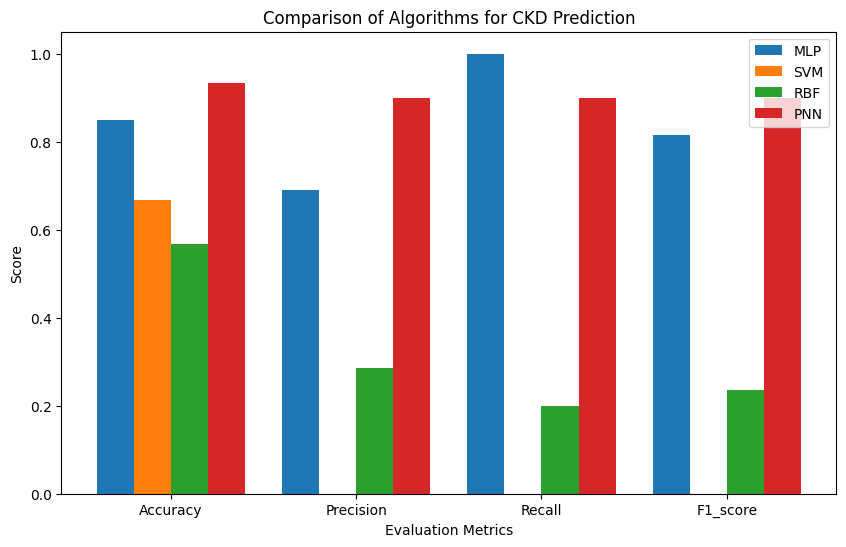

In [77]:
labels = ['Accuracy','Precision','Recall','F1_score']

mlp_scores = list(mlp_results)
svm_scores = list(svm_results)
rbf_scores = list(rbf_results)
pnn_scores = list(pnn_results)

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, mlp_scores, width, label='MLP')
plt.bar(x - 0.5*width, svm_scores, width, label='SVM')
plt.bar(x + 0.5*width, rbf_scores, width, label='RBF')
plt.bar(x + 1.5*width, pnn_scores, width, label='PNN')

plt.xticks(x, labels)

plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Comparison of Algorithms for CKD Prediction")

plt.legend()

plt.show()

In [78]:
results_table = pd.DataFrame({
    "Algorithm": ["MLP", "SVM", "RBF", "PNN"],
    "Accuracy": [mlp_results[0], svm_results[0], rbf_results[0], pnn_results[0]],
    "Precision": [mlp_results[1], svm_results[1], rbf_results[1], pnn_results[1]],
    "Recall": [mlp_results[2], svm_results[2], rbf_results[2], pnn_results[2]],
    "F1 Score": [mlp_results[3], svm_results[3], rbf_results[3], pnn_results[3]]
})

print(results_table)

  Algorithm  Accuracy  Precision  Recall  F1 Score
0       MLP  0.850000   0.689655     1.0  0.816327
1       SVM  0.666667   0.000000     0.0  0.000000
2       RBF  0.566667   0.285714     0.2  0.235294
3       PNN  0.933333   0.900000     0.9  0.900000


In [83]:
results_table

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,MLP,0.850000,0.689655,1.0,0.816327
1,SVM,0.666667,0.000000,0.0,0.000000
2,RBF,0.566667,0.285714,0.2,0.235294
3,PNN,0.933333,0.900000,0.9,0.900000


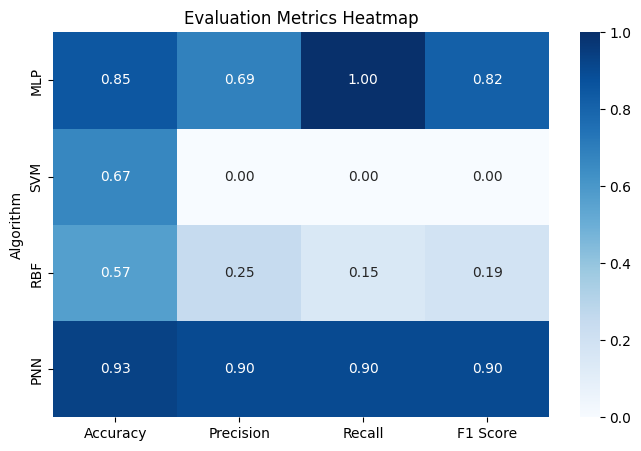

In [84]:
plt.figure(figsize=(8,5))
sns.heatmap(df_metrics.set_index('Algorithm'), annot=True, cmap='Blues', fmt=".2f")
plt.title("Evaluation Metrics Heatmap")
plt.show()